In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [6]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [7]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [8]:
df_picked = data[["temp", "humidity", "winddir", "solarradiation", "cloudcover", "Kwh"]]
print(df_picked.head(), "\n", df_picked.info(), "\n", df_picked.shape)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 21983 entries, 2022-01-01 00:00:00 to 2024-07-04 23:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temp            21983 non-null  float64
 1   humidity        21983 non-null  float64
 2   winddir         21983 non-null  float64
 3   solarradiation  21983 non-null  float64
 4   cloudcover      21983 non-null  float64
 5   Kwh             21983 non-null  float64
dtypes: float64(6)
memory usage: 1.2 MB
                     temp  humidity  winddir  solarradiation  cloudcover  Kwh
datetime                                                                     
2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0  0.0
2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0  0.0
2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9  0.0
2022-01-01 03:00:00   4.0     80.80    294.8             0.0       

In [9]:
x = df_picked.iloc[:, :5]
y = df_picked["Kwh"]

x.head(), y.head(), x.shape, y.shape

(                     temp  humidity  winddir  solarradiation  cloudcover
 datetime                                                                
 2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0
 2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0
 2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9
 2022-01-01 03:00:00   4.0     80.80    294.8             0.0        38.0
 2022-01-01 04:00:00   3.0     93.14    292.3             0.0        41.7,
 datetime
 2022-01-01 00:00:00    0.0
 2022-01-01 01:00:00    0.0
 2022-01-01 02:00:00    0.0
 2022-01-01 03:00:00    0.0
 2022-01-01 04:00:00    0.0
 Name: Kwh, dtype: float64,
 (21983, 5),
 (21983,))

In [10]:
x_train = x.iloc[:17585]
x_test = x.iloc[17585:]
y_train = y.iloc[:17585]
y_test = y.iloc[17585:]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((17585, 5), (17585,), (4398, 5), (4398,))

In [11]:
x_train, x_test

(                     temp  humidity  winddir  solarradiation  cloudcover
 datetime                                                                
 2022-01-01 00:00:00   6.0     75.51    240.0             0.0         0.0
 2022-01-01 01:00:00   6.0     75.51    298.1             0.0         0.0
 2022-01-01 02:00:00   4.9     81.61    301.0             0.0        40.9
 2022-01-01 03:00:00   4.0     80.80    294.8             0.0        38.0
 2022-01-01 04:00:00   3.0     93.14    292.3             0.0        41.7
 ...                   ...       ...      ...             ...         ...
 2024-01-03 12:00:00   7.0     70.49      0.0            62.0        88.3
 2024-01-03 13:00:00   9.0     61.53     30.0            70.0        88.3
 2024-01-03 14:00:00   9.0     57.26      0.0           121.0        88.3
 2024-01-03 15:00:00  10.0     53.55    250.0           162.0        88.3
 2024-01-03 16:00:00  10.0     57.53    170.0            97.0       100.0
 
 [17585 rows x 5 columns],
         

In [12]:
rf_model = RandomForestRegressor()
rf_model.fit(x_train, y_train)

predict_1 = rf_model.predict(x_test)

In [13]:
result_df = pd.DataFrame({"Predictions": predict_1, "Real": y_test})
result_df.head()

,Predictions,Real
datetime,,
2024-01-03 17:00:00,0.003186,0.0
2024-01-03 18:00:00,0.000192,0.0
2024-01-03 19:00:00,0.000366,0.0
2024-01-03 20:00:00,0.000000,0.0
2024-01-03 21:00:00,0.000347,0.0


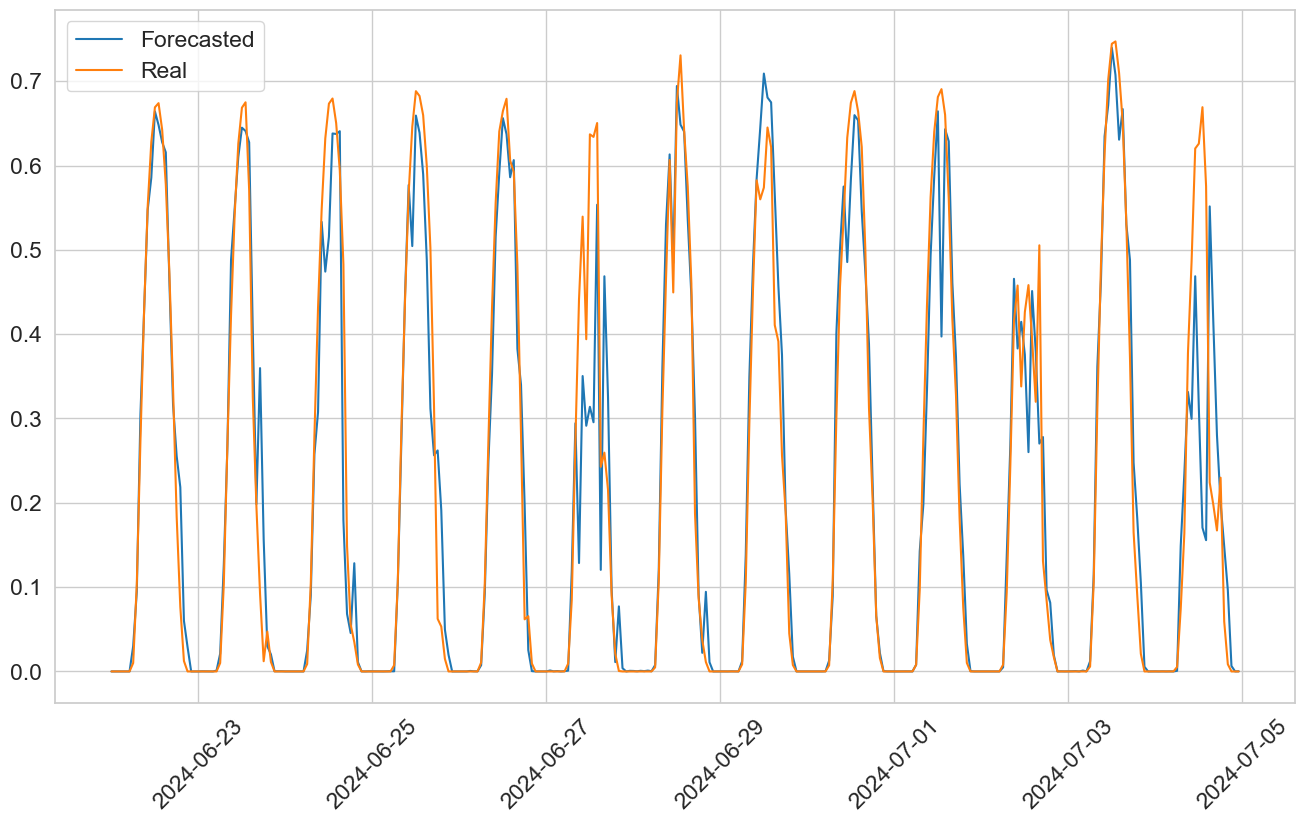

In [18]:
plt.figure(figsize= (16, 9))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)
plt.plot(result_df["Predictions"][-312:], label = "Forecasted")
plt.plot(result_df["Real"][-312:], label = "Real")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [11]:
mse = mean_squared_error(y_test, predict_1)
r2 = r2_score(y_test, predict_1)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.007440960900672794
R^2 Score: 0.8556225898842632


In [12]:
"""from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV with TimeSeriesSplit
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best Parameters: {best_params}")

# Evaluate the best model
y_pred_best = best_model.predict(x_test)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Mean Squared Error: {mse_best}")
print(f"Best R^2 Score: {r2_best}")
"""

'from sklearn.model_selection import TimeSeriesSplit, GridSearchCV\n\n# Initialize TimeSeriesSplit\ntscv = TimeSeriesSplit(n_splits=5)\n\n# Define parameter grid\nparam_grid = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [None, 10, 20],\n    \'min_samples_split\': [2, 5],\n    \'min_samples_leaf\': [1, 2]\n}\n\n# Initialize GridSearchCV with TimeSeriesSplit\ngrid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=tscv, scoring=\'neg_mean_squared_error\', n_jobs=-1)\n\n# Fit GridSearchCV\ngrid_search.fit(x_train, y_train)\n\n# Get the best parameters and model\nbest_params = grid_search.best_params_\nbest_model = grid_search.best_estimator_\n\nprint(f"Best Parameters: {best_params}")\n\n# Evaluate the best model\ny_pred_best = best_model.predict(x_test)\nmse_best = mean_squared_error(y_test, y_pred_best)\nr2_best = r2_score(y_test, y_pred_best)\n\nprint(f"Best Mean Squared Error: {mse_best}")\nprint(f"Best R^2 Score: {r2_best}")\n'

# Standardization

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [14]:
scaler = StandardScaler()
x_2 = scaler.fit_transform(x)
x_2 = pd.DataFrame(x_2)
x_2.head()

,0,1,2,3,4
0,-0.844529,0.677773,0.162968,-0.667591,-1.229281
1,-0.844529,0.677773,0.590086,-0.667591,-1.229281
2,-0.969834,0.947953,0.611405,-0.667591,-0.176131
3,-1.072355,0.912076,0.565826,-0.667591,-0.250804
4,-1.186268,1.458636,0.547448,-0.667591,-0.155531


In [15]:
x_2.index = y.index

In [16]:
x_2, y

(                            0         1         2         3         4
 datetime                                                             
 2022-01-01 00:00:00 -0.844529  0.677773  0.162968 -0.667591 -1.229281
 2022-01-01 01:00:00 -0.844529  0.677773  0.590086 -0.667591 -1.229281
 2022-01-01 02:00:00 -0.969834  0.947953  0.611405 -0.667591 -0.176131
 2022-01-01 03:00:00 -1.072355  0.912076  0.565826 -0.667591 -0.250804
 2022-01-01 04:00:00 -1.186268  1.458636  0.547448 -0.667591 -0.155531
 ...                       ...       ...       ...       ...       ...
 2024-07-04 19:00:00  1.205903 -0.844089 -0.278118  0.115279  0.812646
 2024-07-04 20:00:00  1.091990 -0.856491 -0.331048 -0.278047  0.874444
 2024-07-04 21:00:00  0.864164 -0.479126 -1.601375 -0.633553  0.410955
 2024-07-04 22:00:00  0.750252 -0.179714 -1.601375 -0.667591  0.457304
 2024-07-04 23:00:00  0.522426  0.150702 -1.601375 -0.667591  0.529403
 
 [21982 rows x 5 columns],
 datetime
 2022-01-01 00:00:00    0.0000
 2022-0

In [23]:
x_train_2 = x_2.iloc[:19763]
x_test_2 = x_2.iloc[19763:]
y_train = y.iloc[:19763]
y_test = y.iloc[19763:]

x_train_2.shape, y_train.shape, x_test_2.shape, y_test.shape

((19763, 5), (19763,), (2219, 5), (2219,))

In [24]:
x_train_2, y_train

(                            0         1         2         3         4
 datetime                                                             
 2022-01-01 00:00:00 -0.844529  0.677773  0.162968 -0.667591 -1.229281
 2022-01-01 01:00:00 -0.844529  0.677773  0.590086 -0.667591 -1.229281
 2022-01-01 02:00:00 -0.969834  0.947953  0.611405 -0.667591 -0.176131
 2022-01-01 03:00:00 -1.072355  0.912076  0.565826 -0.667591 -0.250804
 2022-01-01 04:00:00 -1.186268  1.458636  0.547448 -0.667591 -0.155531
 ...                       ...       ...       ...       ...       ...
 2024-04-03 07:00:00 -0.730617 -0.936216  0.824596 -0.656245 -1.216407
 2024-04-03 08:00:00 -0.616704 -0.922928 -1.601375 -0.406634  0.490778
 2024-04-03 09:00:00 -0.274965 -1.009297  1.045139  0.535078  0.058189
 2024-04-03 10:00:00  0.066774 -1.404379 -1.601375  1.227180  1.188587
 2024-04-03 11:00:00  0.066774 -1.201966 -1.601375  1.726401  0.879594
 
 [19763 rows x 5 columns],
 datetime
 2022-01-01 00:00:00    0.0000
 2022-0

In [25]:
rf_model.fit(x_train_2, y_train)

predict_2 = rf_model.predict(x_test_2)

result_df_2 = pd.DataFrame({"Predictions": predict_2, "Real": y_test})
result_df.head()

,Predictions,Real
datetime,,
2024-01-03 17:00:00,0.004556,0.0
2024-01-03 18:00:00,0.000200,0.0
2024-01-03 19:00:00,0.000356,0.0
2024-01-03 20:00:00,0.000056,0.0
2024-01-03 21:00:00,0.000633,0.0


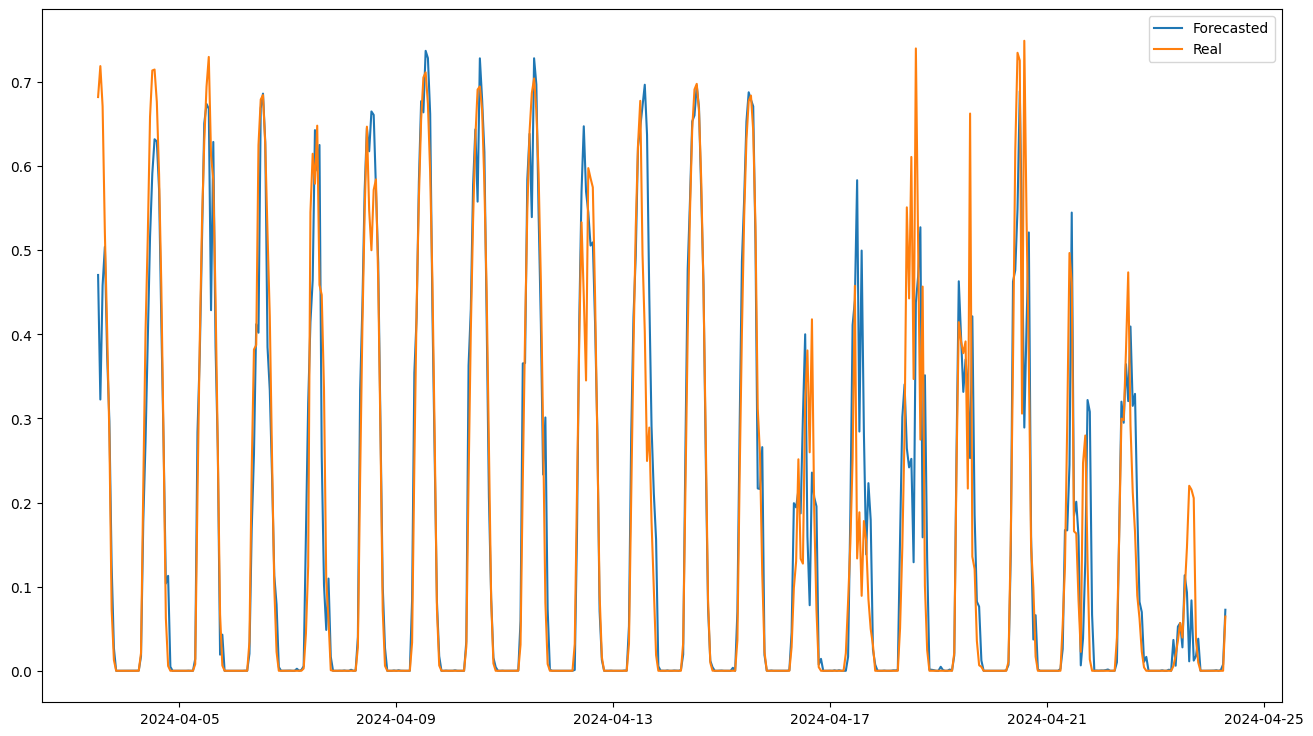

In [26]:
plt.figure(figsize= (16, 9))
plt.plot(result_df_2["Predictions"][:500], label = "Forecasted")
plt.plot(result_df_2["Real"][:500], label = "Real")
plt.legend()
plt.show()

In [27]:
mse_2 = mean_squared_error(y_test, predict_2)
r2_2 = r2_score(y_test, predict_2)

print(f"Mean Squared Error: {mse_2}")
print(f"R^2 Score: {r2_2}")

Mean Squared Error: 0.008778788807794926
R^2 Score: 0.8586249703138419
